<a href="https://colab.research.google.com/github/shriya-0802/OsteoArthritis/blob/main/final_mobilenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from google.colab import drive


In [ ]:
# Mount Google Drive
drive.mount('/content/drive/')



Mounted at /content/drive/


In [ ]:
train_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/train'
test_path  = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/test'
valid_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/val'
original_classes = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']


In [ ]:
# ============================================================================
# 2. APPLY CLAHE TO ALL IMAGES (ENHANCE CONTRAST)
# ============================================================================
def apply_clahe_to_image(img):
    """Apply CLAHE to a single image (assumes RGB)."""
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)



In [ ]:
def preprocess_dataset(data_path):
    """Apply CLAHE to all images in a dataset folder."""
    for class_folder in os.listdir(data_path):
        class_path = os.path.join(data_path, class_folder)
        if os.path.isdir(class_path):
            for fname in os.listdir(class_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(class_path, fname)
                    img = cv2.imread(img_path)
                    if img is not None:
                        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        enhanced = apply_clahe_to_image(img_rgb)
                        cv2.imwrite(img_path, cv2.cvtColor(enhanced, cv2.COLOR_RGB2BGR))

print("Applying CLAHE to all datasets...")
for path in [train_path, test_path, valid_path]:
    preprocess_dataset(path)
print("CLAHE applied.")



Applying CLAHE to all datasets...
CLAHE applied.


In [ ]:
# ============================================================================
# 3. BUILD DATAFRAMES (WITH ALL 5 ORIGINAL CLASSES)
# ============================================================================
def create_dataframe(data_path):
    filepaths, labels = [], []
    for klass in os.listdir(data_path):
        klass_path = os.path.join(data_path, klass)
        if os.path.isdir(klass_path):
            label = original_classes[int(klass)]
            for fname in os.listdir(klass_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    filepaths.append(os.path.join(klass_path, fname))
                    labels.append(label)
    return pd.DataFrame({'filepaths': filepaths, 'labels': labels})

train_df = create_dataframe(train_path)
test_df  = create_dataframe(test_path)
valid_df = create_dataframe(valid_path)

print(f"Train: {len(train_df)} | Test: {len(test_df)} | Valid: {len(valid_df)}")
print("\nOriginal class distribution (train):")
print(train_df['labels'].value_counts())



Train: 5790 | Test: 1656 | Valid: 826

Original class distribution (train):
labels
Healthy     2298
Minimal     1516
Doubtful    1046
Moderate     757
Severe       173
Name: count, dtype: int64


In [ ]:
# ============================================================================
# 4. BALANCE TRAINING DATA (500 SAMPLES PER CLASS)
# ============================================================================
def balance_dataset(df, target_samples=500):
    """Oversample minority classes, undersample majority to target_samples."""
    balanced = []
    for label in df['labels'].unique():
        class_df = df[df['labels'] == label]
        if len(class_df) < target_samples:
            sampled = class_df.sample(n=target_samples, replace=True, random_state=42)
        else:
            sampled = class_df.sample(n=target_samples, random_state=42)
        balanced.append(sampled)
    return pd.concat(balanced, ignore_index=True)

train_df_balanced = balance_dataset(train_df, target_samples=500)
print("\nBalanced training distribution:")
print(train_df_balanced['labels'].value_counts())




Balanced training distribution:
labels
Severe      500
Minimal     500
Moderate    500
Healthy     500
Doubtful    500
Name: count, dtype: int64


In [ ]:
# ============================================================================
# 5. DEFINE GENERATORS (WITH AUGMENTATION FOR TRAIN)
# ============================================================================
img_size = (224, 224)
batch_size = 32

# Training generator with rich augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # scales to [-1,1]
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation/test generator (only preprocessing, no augmentation)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    train_df_balanced,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

valid_gen = val_test_datagen.flow_from_dataframe(
    valid_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

classes = list(train_gen.class_indices.keys())
class_count = len(classes)
print(f"\nClasses: {classes}")



Found 2500 validated image filenames belonging to 5 classes.
Found 826 validated image filenames belonging to 5 classes.
Found 1656 validated image filenames belonging to 5 classes.

Classes: ['Doubtful', 'Healthy', 'Minimal', 'Moderate', 'Severe']


In [ ]:
# ============================================================================
# 6. CLASS WEIGHTS TO HANDLE IMBALANCE IN ORIGINAL TEST SET
# ============================================================================
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df_balanced['labels']),
    y=train_df_balanced['labels']
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")


Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [ ]:
def build_model(num_classes):
    # Load base MobileNetV2 without top, with ImageNet weights
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3),
        pooling='max'
    )
    base_model.trainable = False   # freeze initially

    x = base_model.output
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model, base_model


In [ ]:
# Now call the function
model, base_model = build_model(class_count)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint('/content/drive/MyDrive/Colab Notebooks/best_mobilenet.keras',
                             monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)



In [ ]:
# ============================================================================
# 8. STAGE 1: TRAIN TOP LAYERS (BASE FREEZED)
# ============================================================================
print("\n" + "="*60)
print("STAGE 1: Training top layers (base frozen)")
print("="*60)

history1 = model.fit(
    train_gen,
    epochs=20,
    validation_data=valid_gen,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)




STAGE 1: Training top layers (base frozen)
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - accuracy: 0.2546 - loss: 2.0545
Epoch 1: val_accuracy improved from None to 0.21429, saving model to /content/drive/MyDrive/Colab Notebooks/best_mobilenet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/best_mobilenet.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.2736 - loss: 1.8879 - val_accuracy: 0.2143 - val_loss: 1.8503 - learning_rate: 0.0010
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - accuracy: 0.3057 - loss: 1.6078
Epoch 2: val_accuracy improved from 0.21429 to 0.34383, saving model to /content/drive/MyDrive/Colab Notebooks/best_mobilenet.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/best_mobilenet.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 70s 882ms/step - accuracy: 0.3192 - loss: 1.5715 - val_accuracy: 0.3438 - val_loss: 1.3596 - learning_rate: 0.0010
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step

In [ ]:
# ============================================================================
# 9. STAGE 2: FINE-TUNE LAST 50 LAYERS OF BASE MODEL
# ============================================================================
print("\n" + "="*60)
print("STAGE 2: Fine-tuning last 50 layers of MobileNetV2")
print("="*60)
# Unfreeze last 50 layers
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)





STAGE 2: Fine-tuning last 50 layers of MobileNetV2


In [25]:
history2 = model.fit(
    train_gen,
    epochs=30,
    validation_data=valid_gen,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)



Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.3386 - loss: 1.4559
Epoch 1: val_accuracy improved from 0.41162 to 0.42494, saving model to /content/drive/MyDrive/Colab Notebooks/best_mobilenet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/best_mobilenet.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 92s 861ms/step - accuracy: 0.3344 - loss: 1.4479 - val_accuracy: 0.4249 - val_loss: 1.3104 - learning_rate: 1.0000e-05
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.3484 - loss: 1.4301
Epoch 2: val_accuracy did not improve from 0.42494
79/79 ━━━━━━━━━━━━━━━━━━━━ 48s 613ms/step - accuracy: 0.3624 - loss: 1.4158 - val_accuracy: 0.4153 - val_loss: 1.3275 - learning_rate: 1.0000e-05
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.3731 - loss: 1.3870
Epoch 3: val_accuracy did not improve from 0.42494
79/79 ━━━━━━━━━━━━━━━━━━━━ 48s 605ms/step - accuracy: 0.3728 - loss: 1.3764 - val_accuracy: 0.4165 - val_loss: 1.3268 - l

In [26]:
# ============================================================================
# 10. LOAD BEST MODEL AND EVALUATE ON TEST SET
# ============================================================================
model.load_weights('/content/drive/MyDrive/Colab Notebooks/best_mobilenet.keras')



In [27]:
def evaluate_model(model, test_gen, classes):
    print("\n" + "="*60)
    print("FINAL EVALUATION ON TEST SET")
    print("="*60)
    test_gen.reset()
    y_pred_probs = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes

    accuracy = np.mean(y_pred == y_true) * 100
    print(f"\nTest Accuracy: {accuracy:.2f}%")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes, digits=4))

    return accuracy, y_pred, y_true



FINAL EVALUATION ON TEST SET
52/52 ━━━━━━━━━━━━━━━━━━━━ 28s 447ms/step

Test Accuracy: 43.72%


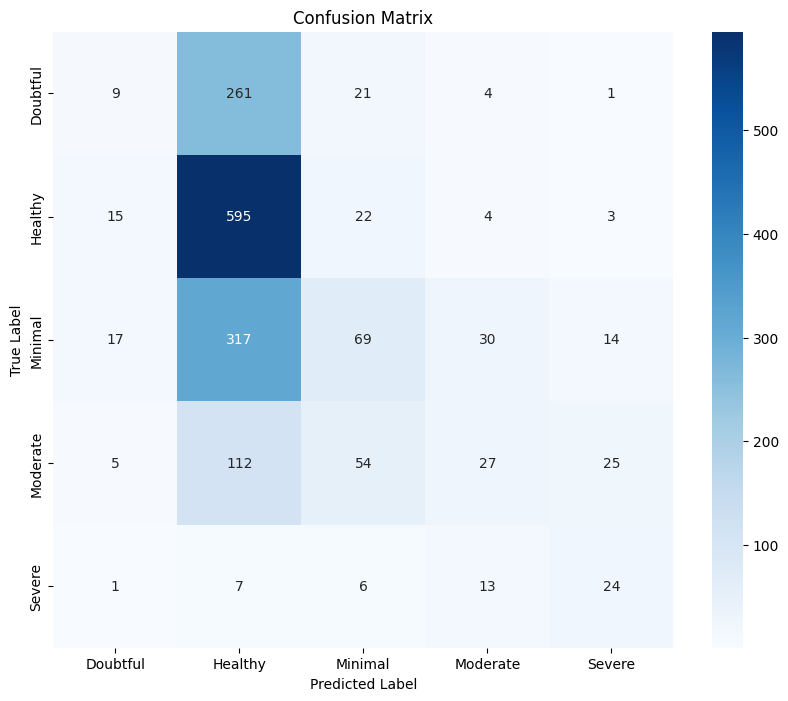


Classification Report:
              precision    recall  f1-score   support

    Doubtful     0.1915    0.0304    0.0525       296
     Healthy     0.4605    0.9311    0.6163       639
     Minimal     0.4012    0.1544    0.2229       447
    Moderate     0.3462    0.1211    0.1794       223
      Severe     0.3582    0.4706    0.4068        51

    accuracy                         0.4372      1656
   macro avg     0.3515    0.3415    0.2956      1656
weighted avg     0.3779    0.4372    0.3440      1656



In [28]:
test_accuracy, _, _ = evaluate_model(model, test_gen, classes)



In [29]:
# ============================================================================
# 11. PLOT TRAINING HISTORY (COMBINED)
# ============================================================================
def plot_history(hist1, hist2):
    acc = hist1.history['accuracy'] + hist2.history['accuracy']
    val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss = hist1.history['loss'] + hist2.history['loss']
    val_loss = hist1.history['val_loss'] + hist2.history['val_loss']
    epochs = range(1, len(acc)+1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
    ax1.plot(epochs, acc, 'b-', label='Training Accuracy')
    ax1.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    ax1.set_title('Training & Validation Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, loss, 'b-', label='Training Loss')
    ax2.plot(epochs, val_loss, 'r-', label='Validation Loss')
    ax2.set_title('Training & Validation Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


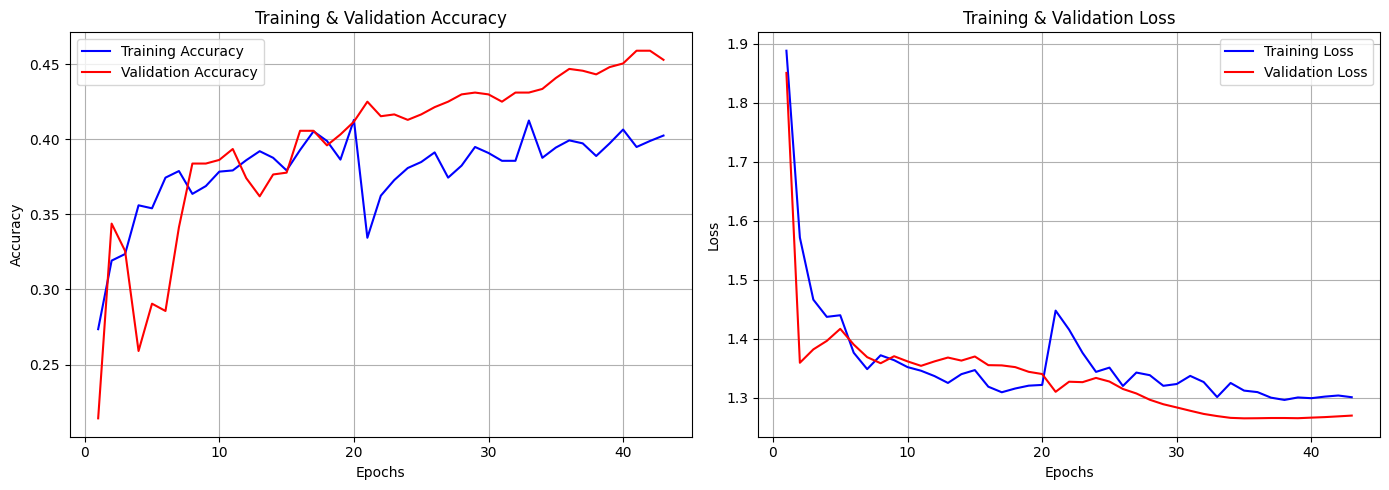

In [30]:
plot_history(history1, history2)




SAMPLE PREDICTIONS ON VALIDATION SET
Image 1: True: Severe     | Pred: Severe     | Conf: 62.82%


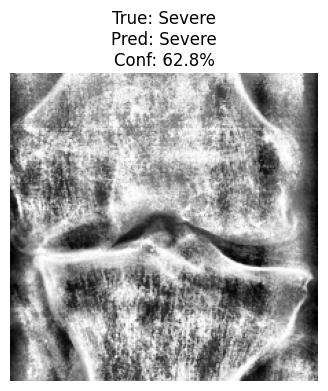

Image 2: True: Doubtful   | Pred: Healthy    | Conf: 36.78%


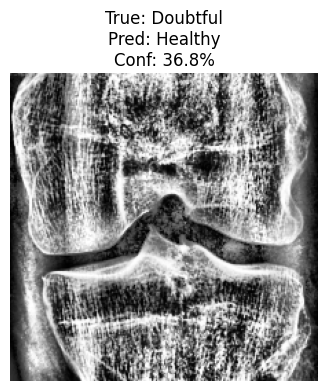

Image 3: True: Doubtful   | Pred: Healthy    | Conf: 31.63%


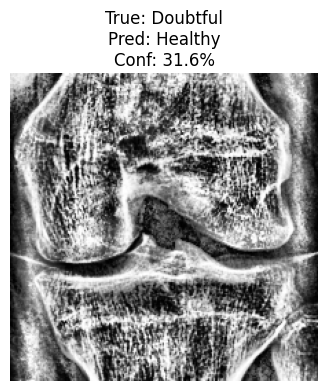

Image 4: True: Doubtful   | Pred: Healthy    | Conf: 27.65%


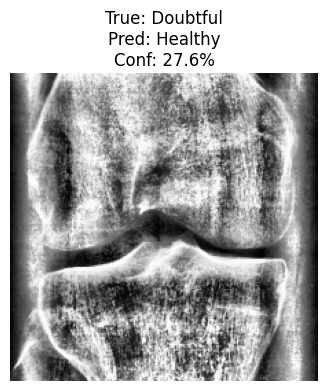

Image 5: True: Doubtful   | Pred: Healthy    | Conf: 34.26%


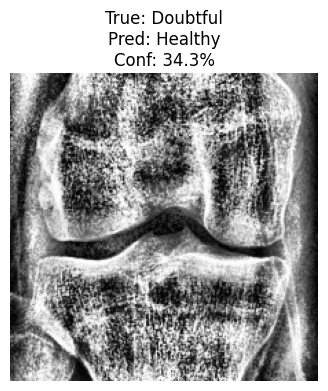

In [31]:
# ============================================================================
# 12. SAMPLE PREDICTIONS (VISUALISE)
# ============================================================================
print("\n" + "="*60)
print("SAMPLE PREDICTIONS ON VALIDATION SET")
print("="*60)

valid_gen.reset()
for i in range(5):
    images, labels = next(valid_gen)
    preds = model.predict(images, verbose=0)
    pred_class = classes[np.argmax(preds[0])]
    true_class = classes[np.argmax(labels[0])]
    confidence = np.max(preds[0]) * 100
    print(f"Image {i+1}: True: {true_class:10s} | Pred: {pred_class:10s} | Conf: {confidence:.2f}%")

    # Show image
    plt.figure(figsize=(4,4))
    # Undo preprocessing (image is in [-1,1]) for display
    img_disp = (images[0] + 1) / 2
    plt.imshow(np.clip(img_disp, 0, 1))
    plt.title(f"True: {true_class}\nPred: {pred_class}\nConf: {confidence:.1f}%")
    plt.axis('off')
    plt.show()



In [32]:
# ============================================================================
# 13. SAVE FINAL MODEL
# ============================================================================
final_save_path = f'/content/drive/MyDrive/Colab Notebooks/MobileNetV2_{test_accuracy:.2f}%.keras'
model.save(final_save_path)
print(f"\nModel saved to: {final_save_path}")


Model saved to: /content/drive/MyDrive/Colab Notebooks/MobileNetV2_43.72%.keras


In [33]:
# Summary
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Train samples (balanced): {len(train_df_balanced)}")
print(f"Validation samples: {len(valid_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Classes: {classes}")
print(f"Test accuracy: {test_accuracy:.2f}%")


TRAINING SUMMARY
Train samples (balanced): 2500
Validation samples: 826
Test samples: 1656
Classes: ['Doubtful', 'Healthy', 'Minimal', 'Moderate', 'Severe']
Test accuracy: 43.72%
